In [5]:
import pandas as pd

tpm_path = "../data/tcga/TcgaTargetGtex_rsem_gene_tpm.gz"
pheno_path = "../data/tcga/TcgaTargetGTEX_phenotype.txt"
mitosis_path = "../data/mitosis/mitosis_ensembl_ids.txt"
fetal_path = "../data/fetal/fetal_mitotic_tpm.tsv"

In [7]:
pheno = pd.read_csv(pheno_path, sep="\t", encoding='latin1')

print(pheno.shape)
print(pheno.columns.tolist())
pheno.head()

(19131, 7)
['sample', 'detailed_category', 'primary disease or tissue', '_primary_site', '_sample_type', '_gender', '_study']


,sample,detailed_category,primary disease or tissue,_primary_site,_sample_type,_gender,_study
0,TCGA-V4-A9EE-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
1,TCGA-VD-AA8N-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
2,TCGA-V4-A9EI-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
3,TCGA-VD-AA8O-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
4,TCGA-WC-A888-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA


In [8]:
# Filter to primary tumors
tumor_samples = pheno[pheno["_sample_type"] == "Primary Tumor"]["sample"].tolist()

print(f"Number of tumor samples: {len(tumor_samples)}")
print(tumor_samples[:5])

Number of tumor samples: 9185
['TCGA-V4-A9EE-01', 'TCGA-VD-AA8N-01', 'TCGA-V4-A9EI-01', 'TCGA-VD-AA8O-01', 'TCGA-WC-A888-01']


In [9]:
mitotic_genes = pd.read_csv(mitosis_path, header=None)[0]
mitotic_genes = mitotic_genes.astype(str).str.split(".").str[0]

print(f"Mitotic genes: {len(mitotic_genes)}")
print(mitotic_genes[:5])

Mitotic genes: 662
0    ENSG00000215114
1    ENSG00000167553
2    ENSG00000172273
3    ENSG00000111206
4    ENSG00000109805
Name: 0, dtype: object


In [10]:
chunks = []
chunk_size = 2000

for i, chunk in enumerate(
    pd.read_csv(
        tpm_path,
        sep="\t",
        compression="gzip",
        chunksize=chunk_size,
        index_col=0
    )
):
    # remove Ensembl version suffix if present
    chunk.index = chunk.index.astype(str).str.split(".").str[0]

    # keep only mitotic genes
    chunk = chunk[chunk.index.isin(mitotic_genes)]

    if not chunk.empty:
        # keep only primary tumor columns
        keep_cols = [c for c in chunk.columns if c in tumor_samples]
        chunk = chunk[keep_cols]
        chunks.append(chunk)

    print(f"Processed chunk {i+1}")

tumor_df = pd.concat(chunks)

print("Tumor matrix shape:", tumor_df.shape)
tumor_df.head()

Processed chunk 1
Processed chunk 2
Processed chunk 3
Processed chunk 4
Processed chunk 5
Processed chunk 6
Processed chunk 7
Processed chunk 8
Processed chunk 9
Processed chunk 10
Processed chunk 11
Processed chunk 12
Processed chunk 13
Processed chunk 14
Processed chunk 15
Processed chunk 16
Processed chunk 17
Processed chunk 18
Processed chunk 19
Processed chunk 20
Processed chunk 21
Processed chunk 22
Processed chunk 23
Processed chunk 24
Processed chunk 25
Processed chunk 26
Processed chunk 27
Processed chunk 28
Processed chunk 29
Processed chunk 30
Processed chunk 31
Tumor matrix shape: (598, 9185)


,TCGA-19-1787-01,TCGA-S9-A7J2-01,TCGA-B5-A5OE-01,TCGA-C8-A1HL-01,TCGA-EW-A2FS-01,TCGA-IR-A3L7-01,TCGA-05-4420-01,TCGA-91-6840-01,TCGA-R6-A8WC-01,TCGA-B6-A402-01,...,TCGA-13-1481-01,TCGA-A8-A09K-01,TCGA-HT-7603-01,TCGA-B5-A3S1-01,TCGA-A2-A1FV-01,TCGA-95-7947-01,TCGA-FI-A2EY-01,TCGA-EJ-5527-01,TCGA-G3-A25X-01,TCGA-24-2254-01
sample,,,,,,,,,,,,,,,,,,,,,
ENSG00000104833,6.6672,6.9974,3.1062,-5.0116,-2.4659,-5.5735,-1.1488,-0.3201,-3.1714,-0.1828,...,4.0100,2.3222,8.2835,3.0602,-5.0116,-2.0529,0.2522,-2.4659,-2.0529,1.7744
ENSG00000164114,1.9111,2.8877,0.4552,0.8408,2.2452,-0.6643,0.6425,2.2206,-1.7809,1.2815,...,0.9862,3.2647,3.6172,2.6232,4.3169,2.3222,-1.3183,4.6059,-3.0469,1.7489
ENSG00000152942,4.0180,4.1891,3.0393,3.8157,3.5098,4.0506,3.8739,3.2572,3.7688,3.5047,...,2.8522,4.3256,4.0100,3.8370,5.3992,3.7324,0.1257,4.5380,1.9340,3.5299
ENSG00000158411,4.4189,5.0180,4.6843,5.0764,5.2739,5.1974,4.8753,4.9860,4.7746,4.5730,...,4.3213,4.8146,4.0331,5.4162,4.8084,5.0014,4.1119,4.3177,3.6804,5.0764
ENSG00000136169,2.0810,1.7995,0.5470,1.7912,1.4808,1.9377,0.5271,1.0711,2.9600,1.6281,...,0.8805,2.7465,1.7097,1.3901,2.6487,2.0776,-0.6416,2.5828,0.7579,1.9073


In [11]:
# drop duplicate gene rows if any appear
tumor_df = tumor_df.groupby(tumor_df.index).mean()

print("Tumor matrix shape after deduplication:", tumor_df.shape)
print("First 5 genes:", tumor_df.index[:5].tolist())

Tumor matrix shape after deduplication: (598, 9185)
First 5 genes: ['ENSG00000000460', 'ENSG00000002822', 'ENSG00000004142', 'ENSG00000004897', 'ENSG00000006611']


In [12]:
tumor_df.to_csv("../data/tcga/primary_tumor_only_mitotic_tpm.csv")
print("Saved tumor mitotic matrix.")

Saved tumor mitotic matrix.


In [13]:
# Load fetal mitotic matrix
fetal_df = pd.read_csv(fetal_path, sep="\t", index_col=0)

print("Fetal matrix shape before cleaning:", fetal_df.shape)
print("First 5 fetal genes:", fetal_df.index[:5].tolist())
fetal_df.head()

Fetal matrix shape before cleaning: (597, 120)
First 5 fetal genes: ['ENSG00000000460', 'ENSG00000002822', 'ENSG00000004142', 'ENSG00000004897', 'ENSG00000006611']


,Gene Name,"5 week post conception, forebrain","7 week post conception, forebrain","8 week post conception, forebrain","9 week post conception, forebrain","10 week post conception, forebrain","11 week post conception, forebrain","12 week post conception, forebrain","13 week post conception, forebrain","18 week post conception, forebrain",...,"13 week post conception, testis","16 week post conception, testis","18 week post conception, testis","19 week post conception, testis","infant, testis","toddler, testis","adolescent, testis","young adult, testis","middle adult, testis","elderly, testis"
Gene ID,,,,,,,,,,,,,,,,,,,,,
ENSG00000000460,C1orf112,34.0,20.0,12.0,8.0,16.0,9.0,7.0,4.0,2.0,...,10.0,9.0,7.0,9.0,5.0,7.0,5.0,7.0,13.0,7.0
ENSG00000002822,MAD1L1,20.0,24.0,17.0,23.0,17.0,26.0,7.0,13.0,16.0,...,18.0,7.0,11.0,11.0,7.0,9.0,16.0,16.0,22.0,27.0
ENSG00000004142,POLDIP2,176.0,201.0,177.0,204.0,191.0,226.0,152.0,207.0,155.0,...,263.0,140.0,126.0,124.0,136.0,144.0,197.0,159.0,207.0,171.0
ENSG00000004897,CDC27,80.0,65.0,57.0,45.0,68.0,43.0,72.0,41.0,38.0,...,39.0,62.0,50.0,48.0,37.0,38.0,26.0,24.0,39.0,24.0
ENSG00000006611,USH1C,2.0,0.3,2.0,3.0,5.0,3.0,0.2,0.9,NaN,...,1.0,0.5,35.0,4.0,6.0,75.0,1.0,1.0,0.7,0.7


In [15]:
# Clean fetal gene IDs
fetal_df.index = fetal_df.index.astype(str).str.split(".").str[0]

# Drop the Gene Name column (non-numeric)
fetal_df = fetal_df.drop(columns=['Gene Name'])

# Drop duplicate genes if any
fetal_df = fetal_df.groupby(fetal_df.index).mean()

print("Fetal matrix shape after cleaning:", fetal_df.shape)
print("First 5 cleaned fetal genes:", fetal_df.index[:5].tolist())

Fetal matrix shape after cleaning: (597, 119)
First 5 cleaned fetal genes: ['ENSG00000000460', 'ENSG00000002822', 'ENSG00000004142', 'ENSG00000004897', 'ENSG00000006611']


In [16]:
# Find shared genes
shared_genes = fetal_df.index.intersection(tumor_df.index)

print(f"Number of shared genes: {len(shared_genes)}")
print("First 10 shared genes:", shared_genes[:10].tolist())

Number of shared genes: 596
First 10 shared genes: ['ENSG00000000460', 'ENSG00000002822', 'ENSG00000004142', 'ENSG00000004897', 'ENSG00000006611', 'ENSG00000006634', 'ENSG00000007168', 'ENSG00000007372', 'ENSG00000008128', 'ENSG00000010244']


In [17]:
# Align both matrices to shared genes
fetal_aligned = fetal_df.loc[shared_genes].copy()
tumor_aligned = tumor_df.loc[shared_genes].copy()

print("Aligned fetal shape:", fetal_aligned.shape)
print("Aligned tumor shape:", tumor_aligned.shape)

Aligned fetal shape: (596, 119)
Aligned tumor shape: (596, 9185)


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# transpose so rows = samples, columns = genes
fetal_T = fetal_aligned.T.copy()
tumor_T = tumor_aligned.T.copy()

# add source labels
fetal_T["source"] = "Fetal"
tumor_T["source"] = "Tumor"

# combine
combined_df = pd.concat([fetal_T, tumor_T], axis=0)
labels = combined_df["source"].copy()
combined_df = combined_df.drop(columns=["source"])

print("Combined shape:", combined_df.shape)
print(labels.value_counts())

Combined shape: (9304, 596)
source
Tumor    9185
Fetal     119
Name: count, dtype: int64


In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_scaled = StandardScaler().fit_transform(combined_df)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

joint_pca_df = pd.DataFrame(pcs, columns=["PC1", "PC2"])
joint_pca_df["source"] = labels.values

print("Explained variance:", pca.explained_variance_ratio_)
joint_pca_df.head()

Explained variance: [0.62078875 0.06170902]


,PC1,PC2,source
0,306.167148,96.315457,Fetal
1,281.549930,28.720587,Fetal
2,231.384825,-27.128116,Fetal
3,215.787823,-19.019949,Fetal
4,248.620508,-14.691103,Fetal


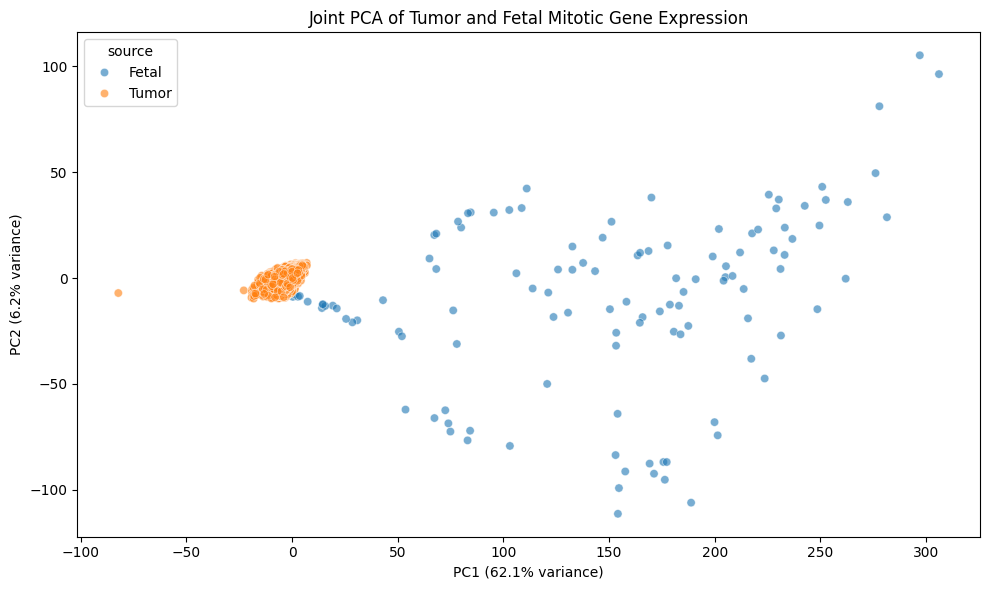

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=joint_pca_df,
    x="PC1",
    y="PC2",
    hue="source",
    alpha=0.6
)

plt.title("Joint PCA of Tumor and Fetal Mitotic Gene Expression")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.tight_layout()
plt.savefig("../results/figures/joint_pca.png", dpi=300, bbox_inches="tight")
plt.show()

In [28]:
# downsample tumors to match fetal size
tumor_sampled = tumor_T.sample(n=119, random_state=42)

# combine again
combined_df = pd.concat([fetal_T, tumor_sampled], axis=0)
labels = combined_df["source"].copy()
combined_df = combined_df.drop(columns=["source"])

print(combined_df.shape)
print(labels.value_counts())

(238, 596)
source
Fetal    119
Tumor    119
Name: count, dtype: int64


In [29]:
X_scaled = StandardScaler().fit_transform(combined_df)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

joint_pca_df = pd.DataFrame(pcs, columns=["PC1", "PC2"])
joint_pca_df["source"] = labels.values

print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [0.6317154  0.07647586]


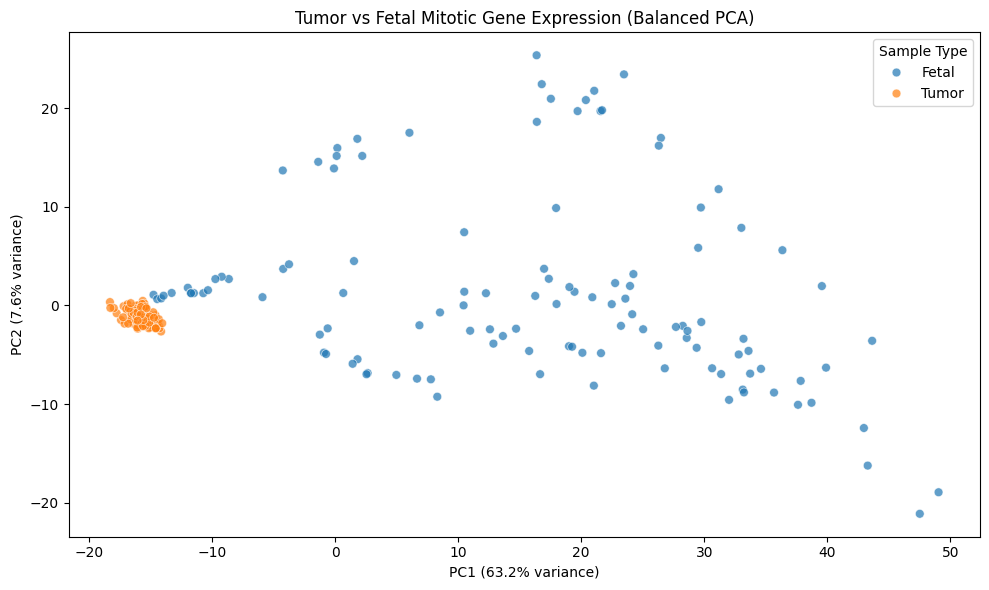

In [31]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=joint_pca_df,
    x="PC1",
    y="PC2",
    hue="source",
    alpha=0.7,
    s=40
)

plt.title("Tumor vs Fetal Mitotic Gene Expression (Balanced PCA)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")

plt.legend(title="Sample Type")
plt.tight_layout()

plt.savefig("../results/figures/joint_pca_balanced.png", dpi=300, bbox_inches="tight")

plt.show()

## Interpretation

After balancing sample sizes between tumor and fetal datasets, PCA reveals that tumor samples cluster tightly within a narrow region of mitotic gene expression space, while fetal samples span a much broader range.

This suggests that tumor proliferation programs may represent a constrained subset of the diverse transcriptional states observed during fetal development, rather than broadly recapitulating fetal gene expression patterns.